# CART Analysis — Human ITL

End-to-end workflow for segmenting, curating, and quantifying CART / B-cell / vasculature / tumour images from LIF stacks.

**Pipeline**
1. **Configure** — set LIF folder + output folder once (next cell).
2. **Imports & functions** — run once per session.
3. **Step 1 — Segment** all LIF images → combined TIFs (raw + labels + metadata).
4. **Step 2 — Review** labels in napari (edit `chip` / `tumour` as needed).
5. **Step 3 — Analyse** curated labels → counts, distances, colocalisation CSVs.
6. **Plots** — CART scatter / bar / enrichment figures.

> Tip: after Step 1, copy the best segmentations into a `best_labels/` folder and point `CURATED_DIR` at it for Step 3.


In [4]:
# ══════════════════════════════════════════════════════════════════════════════
# Imports and GPU check
# ══════════════════════════════════════════════════════════════════════════════
import numpy as np
import pandas as pd
import json
import pathlib
import warnings
import contextlib
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import tifffile
import liffile
import napari
from napari.utils.colormaps import DirectLabelColormap
from scipy.ndimage import distance_transform_edt
from scipy import stats as scipy_stats
from skimage.filters import gaussian, median as median_filter, threshold_li, threshold_mean, threshold_triangle, threshold_yen
from skimage.measure import label, regionprops, regionprops_table
from skimage.morphology import closing, disk, square, erosion, remove_small_holes
from skimage.segmentation import watershed, expand_labels
from skimage.feature import peak_local_max
import joblib
from joblib import Parallel, delayed
from tqdm import tqdm

warnings.filterwarnings("ignore")

# ── GPU availability ──────────────────────────────────────────────────────────
GPU_AVAILABLE = False
try:
    import torch
    GPU_AVAILABLE = torch.cuda.is_available()
except ImportError:
    pass
print(f"GPU available: {GPU_AVAILABLE}")


@contextlib.contextmanager
def tqdm_joblib(tqdm_object):
    """Context manager to patch joblib so it updates a tqdm progress bar."""
    class TqdmBatchCompletionCallback(joblib.parallel.BatchCompletionCallBack):
        def __call__(self, *args, **kwargs):
            tqdm_object.update(n=self.batch_size)
            return super().__call__(*args, **kwargs)
    old_batch_callback = joblib.parallel.BatchCompletionCallBack
    joblib.parallel.BatchCompletionCallBack = TqdmBatchCompletionCallback
    try:
        yield tqdm_object
    finally:
        joblib.parallel.BatchCompletionCallBack = old_batch_callback
        tqdm_object.close()

GPU available: False


## Configuration

Set all paths and parameters **here**. Every downstream cell reads from these variables.


In [5]:
# ══════════════════════════════════════════════════════════════════════════════
# CONFIG — edit these paths then run the rest of the notebook
# ══════════════════════════════════════════════════════════════════════════════
LIF_DIR      = pathlib.Path(r"z:\Marina\Stellaris\2026.03.10_CART\For analysis\4_channels")
LABEL_DIR    = LIF_DIR / "labels"          # Step 1 writes combined TIFs here
CURATED_DIR  = LIF_DIR / "best_labels"     # Step 3 reads curated TIFs from here
OUTPUT_DIR   = CURATED_DIR / "output_figures"

NUM_WORKERS  = 4  # parallel workers for segmentation + analysis

LABEL_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"LIF folder:     {LIF_DIR}")
print(f"Labels folder:  {LABEL_DIR}")
print(f"Curated folder: {CURATED_DIR}")
print(f"Output folder:  {OUTPUT_DIR}")


LIF folder:     z:\Marina\Stellaris\2026.03.10_CART\For analysis\4_channels
Labels folder:  z:\Marina\Stellaris\2026.03.10_CART\For analysis\4_channels\labels
Curated folder: z:\Marina\Stellaris\2026.03.10_CART\For analysis\4_channels\best_labels
Output folder:  z:\Marina\Stellaris\2026.03.10_CART\For analysis\4_channels\best_labels\output_figures


## Functions & constants

Run once per session. Contains segmentation, combined-TIF I/O, the napari review GUI, and analysis helpers.


In [6]:

# ══════════════════════════════════════════════════════════════════════════════
# Constants and functions
# ══════════════════════════════════════════════════════════════════════════════

# ── Label channel convention ──────────────────────────────────────────────────
# Combined TIF layout: (N_raw + 5, Y, X) float32
#   First N_raw channels: raw projection (one per microscope channel)
#   Last 5 channels: chip, vasculature, b_cells, cart_cells, tumour
# N_raw is detected automatically from the file using len(LABEL_NAMES) at the end.
LABEL_NAMES = ["chip", "vasculature", "b_cells", "cart_cells", "tumour"]

GAUSS_SIGMAS_UM = [5, 10, 20, 50, 100]
PROXIMITY_RADII_UM = [5, 10, 20, 30, 40, 50, 100]

REGIONS = ["chip", "not_chip", "tumour", "chip_not_tumour",
           "chip_vasculature", "chip_not_vasculature", "left", "right"]

# ── Raw channel indices ───────────────────────────────────────────────────────
# Set these once to match the current LIF dataset. Negative indices are valid
# (numpy semantics) and useful when channel count varies.
CART_CHANNEL        = 3   # -1 for 5-channel data
BRIGHTFIELD_CHANEL  = 2   #  1 for 5-channel data
B_CELL_CHANNEL      = 0   #  0 for 5-channel data
VASCULATURE_CHANNEL = 1   # -2 for 5-channel data

# Map each named raw channel to its constant. Used for napari/QC display so
# channel names follow the constants (which support negative indices) instead
# of a hardcoded positional list.
RAW_CHANNEL_CONSTANTS = {
    "B cells (raw)":     B_CELL_CHANNEL,
    "Brightfield":       BRIGHTFIELD_CHANEL,
    "Vasculature (raw)": VASCULATURE_CHANNEL,
    "CART (raw)":        CART_CHANNEL,
}


def raw_channel_names(n_raw):
    """Return a list of length n_raw naming each raw channel by its constant.

    Resolves each constant via `% n_raw` so negative indices map to real
    positions. Channels not assigned to any constant are labelled "Ch{i}".
    """
    names = [f"Ch{i}" for i in range(n_raw)]
    for label_text, raw_index in RAW_CHANNEL_CONSTANTS.items():
        resolved = raw_index % n_raw
        if names[resolved].startswith("Ch"):
            names[resolved] = label_text
        else:
            names[resolved] = f"{names[resolved]} / {label_text}"
    return names

EDITABLE_LABELS = ["chip", "tumour"]

LABEL_COLORMAPS = {
    "chip":        DirectLabelColormap(color_dict={0: "transparent", 1: "cyan"}),
    "vasculature": DirectLabelColormap(color_dict={0: "transparent", 1: "magenta"}),
    "b_cells":     DirectLabelColormap(color_dict={0: "transparent", 1: "green"}),
    "cart_cells":  DirectLabelColormap(color_dict={0: "transparent", 1: "red"}),
    "tumour":      DirectLabelColormap(color_dict={0: "transparent", 1: "yellow"}),
}

OVERLAY_COLORS = {
    "Chip":        [0, 1, 1, 0.35],
    "Tumour":      [1, 1, 0, 0.45],
    "Vasculature": [1, 0, 1, 0.40],
    "CART cells":  [1, 0, 0, 0.45],
    "B cells":     [0, 1, 0, 0.45],
}


# ── Helper functions ──────────────────────────────────────────────────────────

def sanitise_filename(image_name):
    """Replace path separators with underscores to create a safe filename."""
    return image_name.replace("/", "_").replace("\\", "_")


def count_cells(region_mask, centroid_rows, centroid_cols):
    """Count how many cell centroids fall inside a binary region mask."""
    if len(centroid_rows) == 0:
        return 0
    return int(region_mask[centroid_rows, centroid_cols].sum())


def add_experiment_info(dataframe):
    """Extract patient, day, flow, fixation, and experiment from image/lif_file columns.

    Adds columns: patient, day, flow, fixation, experiment.
    """
    combined_name = dataframe["image"].astype(str).str.lower() + dataframe["lif_file"].astype(str).str.lower()
    image_name = dataframe["image"].astype(str).str.lower()

    dataframe["patient"] = np.where(combined_name.str.contains("fl32"), "fl32",
                           np.where(combined_name.str.contains("fl12"), "fl12", "unknown"))

    dataframe["day"] = np.where(image_name.str.contains("day10"), "10",
                       np.where(image_name.str.contains("day8"), "8",   
                       np.where(image_name.str.contains("day9"), "9",
                       np.where(image_name.str.contains("day7"), "7",
                       np.where(image_name.str.contains("day6"), "6", "unknown")))))

    dataframe["flow"] = np.where(combined_name.str.contains("3mm"), "3mm",
                        np.where(combined_name.str.contains("7mm"), "7mm", "unknown"))

    dataframe["fixation"] = np.where(combined_name.str.contains("fix"), "fixed", "live")

    dataframe["experiment"] = np.where(
        dataframe["image"].astype(str).str.contains("ARi", case=False, na=False), "ARi", "UTD")

    return dataframe


# ── Segmentation functions ────────────────────────────────────────────────────

def segment_chip(max_projection):
    """Segment the chip region from the brightfield channel.

    Returns (chip_mask, smoothed_brightfield) where chip_mask is a bool array
    marking on-chip pixels and smoothed_brightfield is the pre-processed
    brightfield used downstream for tumour segmentation.
    """
    brightfield = max_projection[BRIGHTFIELD_CHANEL]
    clipped = np.clip(brightfield,
                      np.percentile(brightfield, 25),
                      np.percentile(brightfield, 90))
    smoothed = gaussian(clipped, sigma=7)
    bright_pixels = smoothed > threshold_li(smoothed)
    labelled_bright = label(bright_pixels)
    image_height = smoothed.shape[0]

    # Identify left and right off-chip regions
    left_labels = set(labelled_bright[:, 0]) - {0}
    left_region = np.isin(labelled_bright, list(left_labels))
    left_region = closing(left_region, disk(10))
    left_region = remove_small_holes(left_region, max_size=500000)

    right_labels = set(labelled_bright[:, -1]) - {0}
    right_region = np.isin(labelled_bright, list(right_labels))
    right_region = closing(right_region, disk(10))
    right_region = remove_small_holes(right_region, max_size=500000)

    # Fallback to mean threshold if first pass grabs too much
    if left_region[:, 0].sum() > image_height / 2:
        bright_mean = smoothed > threshold_mean(smoothed)
        labelled_mean = label(bright_mean)
        left_mean_labels = set(labelled_mean[:, 0]) - {0}
        left_region = np.isin(labelled_mean, list(left_mean_labels))
        left_region = closing(left_region, disk(10))
        left_region = remove_small_holes(left_region, max_size=500000)

    if right_region[:, -1].sum() > image_height / 2:
        bright_mean = smoothed > threshold_mean(smoothed)
        labelled_mean = label(bright_mean)
        right_mean_labels = set(labelled_mean[:, -1]) - {0}
        right_region = np.isin(labelled_mean, list(right_mean_labels))
        right_region = closing(right_region, disk(10))
        right_region = remove_small_holes(right_region, max_size=500000)

    chip_mask = (~left_region & ~right_region).astype(bool)
    return chip_mask, smoothed


def segment_tumour(smoothed_brightfield, chip_mask):
    """Segment the tumour from the smoothed brightfield, restricted to chip.

    Uses triangle thresholding with erosion-expansion refinement and
    watershed splitting to isolate the darkest round object near the centre.
    """
    image_centre = np.array([smoothed_brightfield.shape[0] / 2,
                             smoothed_brightfield.shape[1] / 2])

    def pick_best_tumour(labelled_image):
        """Score labelled regions by area, circularity, and centrality."""
        properties = pd.DataFrame(regionprops_table(
            labelled_image, properties=("label", "area", "perimeter", "centroid")))
        properties = properties[properties["area"] >= 0.01 * labelled_image.size] if not properties.empty else properties
        if properties.empty:
            return None
        circularity = (4 * np.pi * properties["area"]) / (properties["perimeter"] ** 2 + 1e-9)
        distance_to_centre = np.hypot(
            properties["centroid-0"] - image_centre[0],
            properties["centroid-1"] - image_centre[1])
        properties["score"] = properties["area"] * circularity / (1 + distance_to_centre)
        return int(properties.loc[properties["score"].idxmax(), "label"])

    tumour_raw = (smoothed_brightfield < threshold_triangle(smoothed_brightfield)) & chip_mask
    labelled_tumour = label(tumour_raw)
    chosen_label = pick_best_tumour(labelled_tumour)
    tumour_mask = (labelled_tumour == chosen_label) if chosen_label is not None else tumour_raw

    # Iterative erosion-expansion to improve solidity
    for erosion_radius, expansion_distance in [(10, 10), (50, 60)]:
        tumour_properties = regionprops(label(tumour_mask))
        if not tumour_properties or tumour_properties[0].solidity >= 0.9:
            break
        eroded = erosion(tumour_mask, disk(erosion_radius))
        eroded_labelled = label(eroded)
        chosen_eroded = pick_best_tumour(eroded_labelled)
        if chosen_eroded is not None:
            tumour_mask = (expand_labels(eroded_labelled, distance=expansion_distance) == chosen_eroded)

    # Watershed: split tumour into at most 2 sub-regions, keep darkest
    tumour_mask = tumour_mask.astype(bool)
    tumour_mask = remove_small_holes(tumour_mask, max_size=500000)
    tumour_pixels = smoothed_brightfield[tumour_mask]
    if tumour_pixels.size > 0:
        smoothed_for_watershed = gaussian(smoothed_brightfield, sigma=10)
        euclidean_distance = distance_transform_edt(tumour_mask)
        peak_coords = peak_local_max(euclidean_distance, min_distance=60,
                                     labels=tumour_mask.astype(int), num_peaks=2)
        if len(peak_coords) >= 2:
            markers = np.zeros_like(tumour_mask, dtype=int)
            for marker_index, (row, col) in enumerate(peak_coords, start=1):
                markers[row, col] = marker_index
            watershed_labels = watershed(smoothed_for_watershed, markers, mask=tumour_mask)
            watershed_medians = {}
            for watershed_value in np.unique(watershed_labels[watershed_labels > 0]):
                watershed_medians[watershed_value] = float(
                    np.median(smoothed_brightfield[watershed_labels == watershed_value]))
            darkest_label = min(watershed_medians, key=watershed_medians.get)
            tumour_mask = (watershed_labels == darkest_label)

    return tumour_mask.astype(bool)


# ── Combined TIF I/O ─────────────────────────────────────────────────────────

def segment_and_save(lif_image, output_directory, lif_path=None):
    """Project a LIF image to 2D, auto-segment, save raw + labels in a (N+5,Y,X) TIF.

    Segments chip, tumour, vasculature, B cells, and CART cells.
    Metadata (image name, LIF file, patient, day, pixel size) is embedded as JSON.
    """
    output_directory = pathlib.Path(output_directory)
    output_directory.mkdir(exist_ok=True, parents=True)
    safe_name = sanitise_filename(lif_image.name)

    lif_stem = lif_path.stem if lif_path else ""
    combined_name_lower = (lif_image.name + lif_stem).lower()
    metadata = {
        "image_name": lif_image.name,
        "lif_file": lif_stem,
        "patient": "fl32" if "fl32" in combined_name_lower else "fl12" if "fl12" in combined_name_lower else "unknown",
        "day": "6" if "day6" in combined_name_lower else "7" if "day7" in combined_name_lower else "unknown",
    }

    max_projection = np.max(lif_image.asarray(), axis=lif_image.dims.index('Z'))

    # Pixel size
    try:
        x_coords = lif_image.coords["X"]
        um_per_px = abs(float(x_coords[1] - x_coords[0])) * 1e6
        if um_per_px <= 0:
            raise ValueError
    except Exception:
        um_per_px = 1.0
        warnings.warn(f"Could not read pixel size for {lif_image.name}, using 1 µm/px")
    metadata["um_per_px"] = um_per_px
    metadata["n_raw_channels"] = int(max_projection.shape[0])

    # Cell segmentation (binary) — remove large objects via smoothed mask
    bcell_raw = max_projection[B_CELL_CHANNEL]
    cart_raw = max_projection[CART_CHANNEL]
    bcell_mask = (bcell_raw > threshold_yen(bcell_raw)).astype(np.uint8)
    cart_mask = (cart_raw > threshold_yen(cart_raw)).astype(np.uint8)

    # Vasculature
    vasculature_raw = max_projection[VASCULATURE_CHANNEL]
    vasculature_median = median_filter(vasculature_raw, footprint=square(7))
    vasculature_smoothed = gaussian(vasculature_median, sigma=3)
    vasculature_mask = vasculature_smoothed > threshold_triangle(vasculature_smoothed)
    labelled_vasculature = label(vasculature_mask)
    vasculature_properties = pd.DataFrame(regionprops_table(
        labelled_vasculature, properties=("area", "solidity")))
    if float(vasculature_properties.loc[vasculature_properties["area"].idxmax(), "solidity"]) > 0.9:
        vasculature_mask = vasculature_smoothed > threshold_li(vasculature_smoothed)
    vasculature_mask = vasculature_mask.astype(np.uint8)

    # Chip and tumour
    chip_mask, smoothed_brightfield = segment_chip(max_projection)
    tumour_mask = segment_tumour(smoothed_brightfield, chip_mask).astype(np.uint8)

    # Stack labels: (5, Y, X) — chip, vasculature, b_cells, cart_cells, tumour
    labels_stack = np.stack([chip_mask.astype(np.uint8), vasculature_mask,
                             bcell_mask, cart_mask, tumour_mask], axis=0)

    combined = np.concatenate([
        max_projection.astype(np.float32),
        labels_stack.astype(np.float32),
    ], axis=0)

    tifffile.imwrite(str(output_directory / f"{safe_name}.tif"),
                     combined, imagej=True,
                     metadata={'Info': json.dumps(metadata)})

    print(f"  Saved: {safe_name}")
    return safe_name


def load_combined_tif(filepath):
    """Load a combined TIF and return (raw, labels, metadata_json_string).

    raw:    (N_raw, Y, X) float32 — raw projection channels.
    labels: (5, Y, X) uint8       — chip, vasculature, b_cells, cart_cells, tumour.
    metadata_json_string: str or None — embedded JSON metadata.

    The split between raw and labels is computed from the END of the stack
    using len(LABEL_NAMES), so any number of raw channels is supported.
    """
    n_label_channels = len(LABEL_NAMES)
    with tifffile.TiffFile(str(filepath)) as tif:
        data = tif.asarray()
        imagej_metadata = tif.imagej_metadata or {}
        metadata_json_string = imagej_metadata.get('Info', None)
    raw = data[:-n_label_channels]
    labels = data[-n_label_channels:].astype(np.uint8)
    return raw, labels, metadata_json_string


def save_combined_tif(filepath, raw, labels, metadata_json_string=None):
    """Re-save a combined TIF from raw + labels arrays."""
    combined = np.concatenate([
        raw.astype(np.float32),
        labels.astype(np.float32),
    ], axis=0)
    metadata = {'Info': metadata_json_string} if metadata_json_string else {}
    tifffile.imwrite(str(filepath), combined, imagej=True, metadata=metadata)


# ── Napari review ─────────────────────────────────────────────────────────────

def review_in_napari(label_directory):
    """Load ONE combined TIF at a time into Napari for manual correction.

    Returns (viewer, controls) where controls has .next(), .prev(), .save(),
    .goto(i), and .reset_label(name).  Only the current image's layers are
    in memory at any time.  Chip and tumour labels are editable.
    """
    from magicgui import magicgui
    label_directory = pathlib.Path(label_directory)

    image_list = sorted(label_directory.glob("*.tif"))
    if not image_list:
        print("No images found in", label_directory)
        return None, None

    viewer = napari.Viewer()
    state = {"idx": 0, "label_layers": {}, "raw": None, "labels": None,
             "dirty": False, "meta_info": None}

    def save_current():
        """Write any edited labels back to the combined TIF."""
        if not state["label_layers"] or state["labels"] is None:
            return
        tif_path = image_list[state["idx"]]
        updated_labels = state["labels"].copy()
        for label_name, layer in state["label_layers"].items():
            label_index = LABEL_NAMES.index(label_name)
            updated_labels[label_index] = (layer.data > 0).astype(np.uint8)
        save_combined_tif(tif_path, state["raw"], updated_labels, state["meta_info"])
        state["labels"] = updated_labels
        state["dirty"] = False
        print(f"  Saved: {tif_path.name}")

    def load_image(index):
        """Clear viewer and load image at the given index."""
        if state["dirty"]:
            save_current()

        state["label_layers"] = {}
        viewer.layers.clear()

        tif_path = image_list[index]
        state["idx"] = index
        safe = tif_path.stem

        raw, labels, metadata_json_string = load_combined_tif(tif_path)
        state["raw"] = raw
        state["labels"] = labels.copy()
        state["meta_info"] = metadata_json_string

        n_raw = raw.shape[0]
        channel_names = raw_channel_names(n_raw)
        brightfield_index = BRIGHTFIELD_CHANEL % n_raw
        for channel_index in range(n_raw):
            viewer.add_image(raw[channel_index], name=channel_names[channel_index],
                             visible=(channel_index == brightfield_index), blending="additive")

        for label_name in EDITABLE_LABELS:
            label_index = LABEL_NAMES.index(label_name)
            layer = viewer.add_labels(
                labels[label_index],
                name=label_name,
                colormap=LABEL_COLORMAPS.get(label_name),
            )
            state["label_layers"][label_name] = layer

        viewer.title = f"[{index + 1}/{len(image_list)}] {safe}"
        state["dirty"] = True
        print(f"Loaded [{index + 1}/{len(image_list)}]: {safe}")

    def navigate_next():
        """Go to the next image."""
        if state["idx"] < len(image_list) - 1:
            load_image(state["idx"] + 1)
        else:
            print("Already at last image.")

    def navigate_prev():
        """Go to the previous image."""
        if state["idx"] > 0:
            load_image(state["idx"] - 1)
        else:
            print("Already at first image.")

    def goto_image(index):
        """Jump to a specific image by index."""
        if 0 <= index < len(image_list):
            load_image(index)
        else:
            print(f"Index {index} out of range (0–{len(image_list)-1})")

    def reset_label(label_name):
        """Replace a label layer with a blank one for re-drawing."""
        if label_name not in EDITABLE_LABELS:
            print(f"Unknown label '{label_name}'. Choose from: {EDITABLE_LABELS}")
            return
        old_layer = state["label_layers"][label_name]
        shape = old_layer.data.shape
        viewer.layers.remove(old_layer)
        blank = np.zeros(shape, dtype=old_layer.data.dtype)
        new_layer = viewer.add_labels(
            blank, name=label_name, colormap=LABEL_COLORMAPS.get(label_name))
        state["label_layers"][label_name] = new_layer
        state["dirty"] = True
        print(f"  Reset '{label_name}' to blank. Paint with value 1 to redraw.")

    @viewer.bind_key("n")
    def key_next(viewer):
        navigate_next()

    @viewer.bind_key("b")
    def key_prev(viewer):
        navigate_prev()

    @viewer.bind_key("Control-s")
    def key_save(viewer):
        save_current()

    _reset_label = reset_label  # capture before magicgui shadows the name

    @magicgui(
        call_button="Reset Label",
        label_name={"choices": EDITABLE_LABELS, "label": "Label to reset"},
    )
    def reset_widget(label_name=EDITABLE_LABELS[0]):
        _reset_label(label_name)

    viewer.window.add_dock_widget(reset_widget, name="Reset Label", area="right")
    load_image(0)
    print(f"\n{len(image_list)} images found. Shortcuts: n=next, b=back, Ctrl+S=save")
    print("Labels auto-save when you navigate to the next/prev image.")

    class Controls:
        """Returned handle for programmatic navigation."""
        next = staticmethod(navigate_next)
        prev = staticmethod(navigate_prev)
        save = staticmethod(save_current)
        goto = staticmethod(goto_image)
        reset_label = staticmethod(_reset_label)
        n_images = len(image_list)

    return viewer, Controls()


# ── QC figure ─────────────────────────────────────────────────────────────────

def save_output_figure(image_name, panels, output_directory):
    """Save a 2-row QC figure showing raw channels with mask overlays.

    panels: list of (title, raw_channel_2d, mask_2d) tuples.
    Top row = raw channel (gray), bottom row = mask overlaid in colour.
    """
    num_panels = len(panels)
    fig, axes = plt.subplots(nrows=2, ncols=num_panels,
                             figsize=(4 * num_panels, 7), constrained_layout=True)
    fig.suptitle(f"Segmentation — {image_name}", fontsize=11, fontweight="bold")
    for col, (title, raw_channel, mask) in enumerate(panels):
        axes[0, col].imshow(raw_channel, cmap="gray", interpolation="none")
        axes[0, col].set_title(title, fontsize=9)
        axes[0, col].axis("off")

        axes[1, col].imshow(raw_channel, cmap="gray", interpolation="none")
        overlay = np.zeros((*raw_channel.shape, 4), dtype=float)
        color = OVERLAY_COLORS.get(title, [1, 0.2, 0.2, 0.5])
        overlay[mask, :] = color
        axes[1, col].imshow(overlay, interpolation="none")
        axes[1, col].set_title(f"{title} mask", fontsize=8)
        axes[1, col].axis("off")

    safe = image_name.replace('/', '_').replace('\\', '_')
    output_path = output_directory / f"{safe}_segmentations.png"
    fig.savefig(output_path, dpi=100, bbox_inches="tight")
    plt.close(fig)
    return output_path


# ── Analysis functions ────────────────────────────────────────────────────────

def analyse_one_image(tif_path, output_folder=None):
    """Analyse a single combined TIF: cell counts, distances, and colocalisation.

    Returns (counts_dataframe, distances_dataframe, colocalisation_dataframe).
    """
    raw, labels_array, metadata_json_string = load_combined_tif(tif_path)
    metadata = json.loads(metadata_json_string) if metadata_json_string else {}
    um_per_px = metadata.get("um_per_px", 1.0)

    # Unpack label channels
    chip_mask = labels_array[0].astype(bool)
    vasculature_mask = labels_array[1].astype(bool)
    bcell_mask = labels_array[2].astype(bool)
    cart_mask = labels_array[3].astype(bool)
    tumour_mask = labels_array[4].astype(bool)

    # Recompute left/right from chip
    not_chip = ~chip_mask
    labelled_not_chip = label(not_chip)
    left_mask = np.zeros_like(chip_mask)
    right_mask = np.zeros_like(chip_mask)
    for region_props in regionprops(labelled_not_chip):
        coords = region_props.coords
        if np.any(coords[:, 1] == 0):
            left_mask[labelled_not_chip == region_props.label] = True
        if np.any(coords[:, 1] == chip_mask.shape[1] - 1):
            right_mask[labelled_not_chip == region_props.label] = True

    # Build regions dictionary
    region_masks = {
        "chip":                 chip_mask,
        "not_chip":             not_chip,
        "tumour":               chip_mask & tumour_mask,
        "chip_not_tumour":      chip_mask & ~tumour_mask,
        "chip_vasculature":     chip_mask & vasculature_mask,
        "chip_not_vasculature": chip_mask & ~vasculature_mask,
        "left":                 left_mask.astype(bool),
        "right":                right_mask.astype(bool),
    }

    tumour_distance_map = distance_transform_edt(~tumour_mask)
    safe = tif_path.stem
    image_name = metadata.get("image_name", safe)
    base_metadata = {key: metadata.get(key, "unknown") for key in ("lif_file", "patient", "day")}

    # ── Counting ──────────────────────────────────────────────────────────────
    count_records = []
    distance_records = []

    for cell_type_name, cell_mask in [("CART cells", cart_mask), ("B cells", bcell_mask)]:
        labelled_cells = label(cell_mask)
        total_cell_count = int(labelled_cells.max())
        total_positive_pixels = int(cell_mask.sum())

        if total_cell_count > 0:
            centroid_table = pd.DataFrame(regionprops_table(
                labelled_cells, properties=("centroid",)))
            centroid_rows = np.clip(
                np.round(centroid_table["centroid-0"].values).astype(int),
                0, cell_mask.shape[0] - 1)
            centroid_cols = np.clip(
                np.round(centroid_table["centroid-1"].values).astype(int),
                0, cell_mask.shape[1] - 1)
        else:
            centroid_rows = np.array([], dtype=int)
            centroid_cols = np.array([], dtype=int)

        total_image_pixels = int(cell_mask.shape[0] * cell_mask.shape[1])
        count_records.append(dict(
            **base_metadata, image=image_name, cell_type=cell_type_name,
            region="overall", cell_count=total_cell_count,
            positive_pixels=total_positive_pixels,
            region_area_px=total_image_pixels,
            positive_pixel_pct=100.0 * total_positive_pixels / total_image_pixels if total_image_pixels else 0.0))

        for region_name, region_mask in region_masks.items():
            region_cell_count = count_cells(region_mask, centroid_rows, centroid_cols)
            region_positive_pixels = int(np.sum(cell_mask & region_mask))
            region_area = int(region_mask.sum())
            count_records.append(dict(
                **base_metadata, image=image_name, cell_type=cell_type_name,
                region=region_name, cell_count=region_cell_count,
                positive_pixels=region_positive_pixels,
                region_area_px=region_area,
                positive_pixel_pct=100.0 * region_positive_pixels / region_area if region_area else 0.0))

        if total_cell_count > 0:
            distances_um = tumour_distance_map[centroid_rows, centroid_cols] * um_per_px
            for row, col, distance in zip(centroid_rows, centroid_cols, distances_um):
                distance_record = dict(
                    **base_metadata, image=image_name, cell_type=cell_type_name,
                    distance_from_tumour_um=float(distance))
                for region_name, region_mask in region_masks.items():
                    distance_record[f"in_{region_name}"] = bool(region_mask[row, col])
                distance_records.append(distance_record)

    # ── Colocalisation ────────────────────────────────────────────────────────
    bcell_channel = raw[B_CELL_CHANNEL].astype(float)
    cart_channel = raw[CART_CHANNEL].astype(float)
    colocalisation_records = []

    for sigma_um in GAUSS_SIGMAS_UM:
        sigma_px = sigma_um / um_per_px
        bcell_blurred = gaussian(bcell_channel, sigma=sigma_px)
        cart_blurred = gaussian(cart_channel, sigma=sigma_px)
        for region_name, region_mask in region_masks.items():
            bcell_values = bcell_blurred[region_mask]
            cart_values = cart_blurred[region_mask]
            pearson_correlation = (np.nan if len(bcell_values) < 20
                                   else float(scipy_stats.pearsonr(bcell_values, cart_values)[0]))
            colocalisation_records.append(dict(
                **base_metadata, image=image_name, method="coarse_pearson",
                param_um=sigma_um, region=region_name, score=pearson_correlation))

    cart_distance_transform = distance_transform_edt(~cart_mask)
    bcell_distance_transform = distance_transform_edt(~bcell_mask)

    for radius_um in PROXIMITY_RADII_UM:
        radius_px = radius_um / um_per_px
        cart_within_radius = cart_distance_transform <= radius_px
        bcell_within_radius = bcell_distance_transform <= radius_px
        for region_name, region_mask in region_masks.items():
            bcell_in_region = bcell_mask & region_mask
            cart_in_region = cart_mask & region_mask
            bcell_pixel_count = int(bcell_in_region.sum())
            cart_pixel_count = int(cart_in_region.sum())
            bcell_near_cart = (float((bcell_in_region & cart_within_radius).sum()) / bcell_pixel_count
                               if bcell_pixel_count else np.nan)
            cart_near_bcell = (float((cart_in_region & bcell_within_radius).sum()) / cart_pixel_count
                               if cart_pixel_count else np.nan)
            colocalisation_records.append(dict(
                **base_metadata, image=image_name, method="B_near_CART",
                param_um=radius_um, region=region_name, score=bcell_near_cart))
            colocalisation_records.append(dict(
                **base_metadata, image=image_name, method="CART_near_B",
                param_um=radius_um, region=region_name, score=cart_near_bcell))

    # ── QC overlay figure ─────────────────────────────────────────────────────
    if output_folder is not None:
        panels = [
            ("Chip",        raw[BRIGHTFIELD_CHANEL],  chip_mask),
            ("Tumour",      raw[BRIGHTFIELD_CHANEL],  tumour_mask),
            ("Vasculature", raw[VASCULATURE_CHANNEL], vasculature_mask),
            ("CART cells",  raw[CART_CHANNEL],        cart_mask),
            ("B cells",     raw[B_CELL_CHANNEL],      bcell_mask),
        ]
        save_output_figure(image_name, panels, pathlib.Path(output_folder))

    return (pd.DataFrame(count_records),
            pd.DataFrame(distance_records),
            pd.DataFrame(colocalisation_records))


def analyse_from_labels(label_directory, output_folder, num_workers=4):
    """Load corrected combined TIFs and run counting + colocalisation in parallel.

    Returns (all_results, all_distances, colocalisation_dataframe).
    CSVs are also saved to output_folder.
    """
    label_directory = pathlib.Path(label_directory)
    output_folder = pathlib.Path(output_folder)
    output_folder.mkdir(exist_ok=True, parents=True)

    tif_files = sorted(label_directory.glob("*.tif"))

    with tqdm_joblib(tqdm(desc="Analysing corrected labels", total=len(tif_files))) as progress:
        results = Parallel(n_jobs=num_workers, prefer="threads")(
            delayed(analyse_one_image)(tif_path, output_folder) for tif_path in tif_files
        )

    all_results = pd.concat([result[0] for result in results], ignore_index=True)
    all_distances = pd.concat([result[1] for result in results], ignore_index=True)
    colocalisation_dataframe = pd.concat([result[2] for result in results], ignore_index=True)

    all_results.to_csv(output_folder / "all_counts_inc_percentage.csv", index=False)
    all_distances.to_csv(output_folder / "all_distances_inc_percentage.csv", index=False)
    colocalisation_dataframe.to_csv(output_folder / "all_colocalisation_inc_percentage.csv", index=False)

    return all_results, all_distances, colocalisation_dataframe


LIF file:   CART_day6_FL32.lif
Image name: FL32_ARi1_Merged


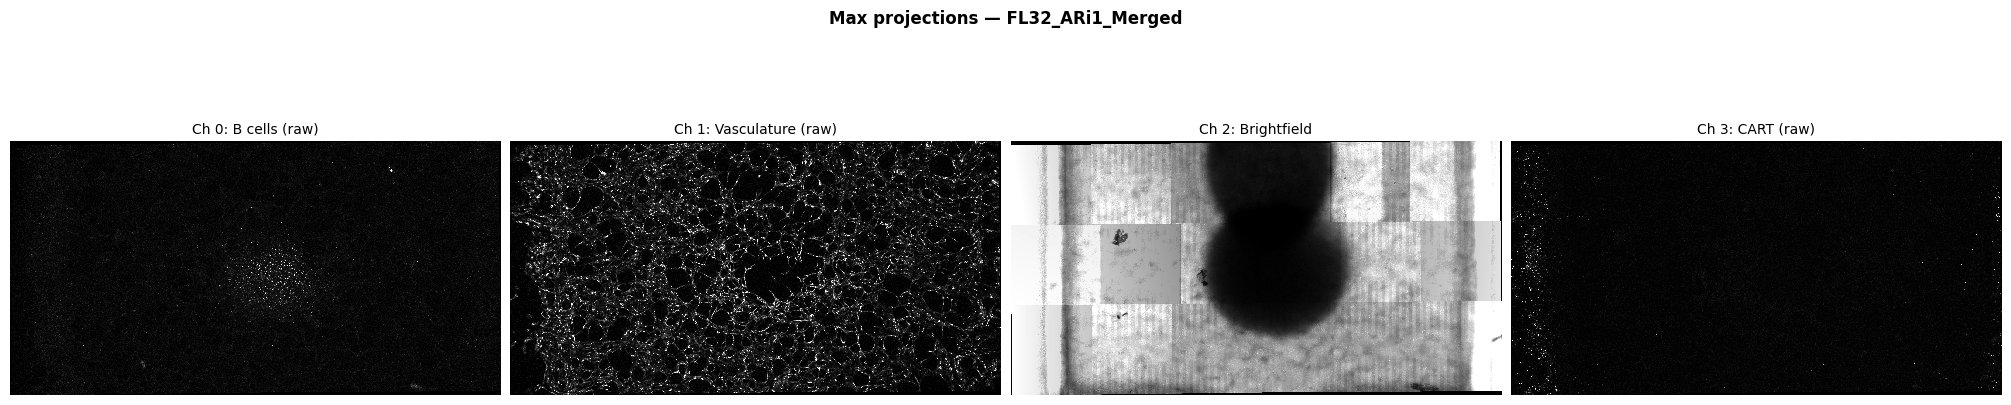

Array shape (C, Y, X): (4, 2106, 4071)
Resolved channel assignments:
  B cells (raw)        → constant   0 → channel 0
  Brightfield          → constant   2 → channel 2
  Vasculature (raw)    → constant   1 → channel 1
  CART (raw)           → constant   3 → channel 3


In [7]:
# ── Preview: max projections of each channel in the first LIF image ──────────
# Sanity check that the channel constants above match the actual data.
lif_files_preview = sorted(LIF_DIR.glob("*.lif"))
with liffile.LifFile(lif_files_preview[0]) as lif:
    first_image = lif.images[0]
    print(f"LIF file:   {lif_files_preview[0].name}")
    print(f"Image name: {first_image.name}")
    stack = first_image.asarray()
    z_axis = first_image.dims.index('Z')
    max_proj = np.max(stack, axis=z_axis)  # shape: (C, Y, X)
    n_channels = max_proj.shape[0]

# Use the same naming function napari uses, so labels here match labels there.
channel_names = raw_channel_names(n_channels)

fig, axes = plt.subplots(1, n_channels, figsize=(5 * n_channels, 5), constrained_layout=True)
if n_channels == 1:
    axes = [axes]
for ch, ax in enumerate(axes):
    ax.imshow(max_proj[ch], cmap="gray", interpolation="none")
    ax.set_title(f"Ch {ch}: {channel_names[ch]}", fontsize=10)
    ax.axis("off")
fig.suptitle(f"Max projections — {first_image.name}", fontsize=12, fontweight="bold")
plt.show()

print(f"Array shape (C, Y, X): {max_proj.shape}")
print("Resolved channel assignments:")
for label_text, raw_index in RAW_CHANNEL_CONSTANTS.items():
    print(f"  {label_text:20s} → constant {raw_index:>3d} → channel {raw_index % n_channels}")


In [8]:
# ── Plotting helper ───────────────────────────────────────────────────────────

def add_condition_label(dataframe):
    """Attach 'condition' (Day{d} {flow} {experiment}) + 'sort_key' columns.

    Requires `add_experiment_info` to have been applied. Returns
    (sorted_dataframe, condition_order) where condition_order is the unique
    list of conditions ordered by day → flow (3mm<7mm) → experiment (ARi<UTD).
    """
    dataframe = dataframe.copy()
    dataframe["condition"] = (
        "Day" + dataframe["day"].astype(str) + " " +
        dataframe["flow"].astype(str) + " " +
        dataframe["experiment"].astype(str)
    )
    dataframe["sort_key"] = (
        dataframe["day"].astype(int) * 100 +
        dataframe["flow"].map({"3mm": 0, "7mm": 1}).fillna(9) * 10 +
        dataframe["experiment"].map({"ARi": 0, "UTD": 1}).fillna(9)
    )
    dataframe = dataframe.sort_values("sort_key")
    condition_order = list(dict.fromkeys(dataframe["condition"]))
    return dataframe, condition_order


## Step 1 — Segment all LIF images

Auto-segments every image in every LIF file in `LIF_DIR` and writes one combined TIF per image to `LABEL_DIR` (channels: 4 raw + 5 labels + embedded metadata).


In [ ]:
# Step 1 — segment every image in every LIF file in LIF_DIR → LABEL_DIR
lif_files = sorted(LIF_DIR.glob("*.lif"))
print(f"Found {len(lif_files)} LIF files in {LIF_DIR}")

tasks = []
for lif_path in lif_files:
    with liffile.LifFile(lif_path) as lif:
        n_images = len(lif.images)
        print(f"  {lif_path.name}: {n_images} images")
        tasks.extend((lif_path, i) for i in range(n_images))


def process_one_lif_image(lif_path, image_index):
    """Segment a single image from a LIF file and save the combined TIF."""
    with liffile.LifFile(lif_path) as lif:
        return segment_and_save(lif.images[image_index], LABEL_DIR, lif_path=lif_path)


with tqdm_joblib(tqdm(desc="Segmenting images", total=len(tasks))) as progress:
    Parallel(n_jobs=NUM_WORKERS, prefer="threads")(
        delayed(process_one_lif_image)(lif_path, image_index)
        for lif_path, image_index in tasks
    )

print(f"\nAll labels saved to: {LABEL_DIR}")


Found 3 LIF files in z:\Marina\Stellaris\2026.03.10_CART\For analysis\4_channels
  CART_day6_FL32.lif: 8 images
  CART_day7_FL12.lif: 8 images
  CART_day7_FL32.lif: 8 images


Segmenting images:   0%|          | 0/24 [00:00<?, ?it/s]

## Step 2 — Review & edit in napari

Opens one image at a time from `LABEL_DIR`. Use the viewer to correct `chip` and `tumour` masks.

**Shortcuts:** `n` = next · `b` = back · `Ctrl+S` = save · *Reset Label* widget (right panel) wipes a layer for re-drawing.

Edits auto-save when you navigate. Programmatic control: `controls.next()`, `controls.prev()`, `controls.save()`, `controls.goto(i)`, `controls.reset_label("tumour")`.

> When satisfied, copy your best TIFs from `LABEL_DIR` into `CURATED_DIR` before running Step 3.


In [33]:
# Step 2 — open labels in napari for review
viewer, controls = review_in_napari(LABEL_DIR)


Loaded [1/8]: FL12_day6_ARi1

8 images found. Shortcuts: n=next, b=back, Ctrl+S=save
Labels auto-save when you navigate to the next/prev image.


In [7]:
# Optional — napari navigation helpers (run as needed)
# controls.next()
# controls.prev()
# controls.goto(9)
controls.save()


  Saved: FL12_day6_ARi1.tif


## Step 3 — Analyse curated labels

Reads combined TIFs from `CURATED_DIR`, computes cell counts, tumour-distance distributions, and B↔CART colocalisation per region. Writes three CSVs + per-image QC PNGs to `OUTPUT_DIR`.


In [8]:
# Step 3 — run analysis on curated labels
all_results, all_distances, colocalisation_dataframe = analyse_from_labels(
    CURATED_DIR, OUTPUT_DIR, num_workers=NUM_WORKERS)

# Attach patient / day / flow / fixation / experiment columns in-place
for dataframe in (all_results, all_distances, colocalisation_dataframe):
    add_experiment_info(dataframe)

print(f"all_results:              {len(all_results)} rows")
print(f"all_distances:            {len(all_distances)} rows")
print(f"colocalisation_dataframe: {len(colocalisation_dataframe)} rows")


Analysing corrected labels: 0it [00:00, ?it/s]


ValueError: No objects to concatenate

## Plots

CART scatter, fixed-vs-live bars, and normalised enrichment. All figures are written to `OUTPUT_DIR`.


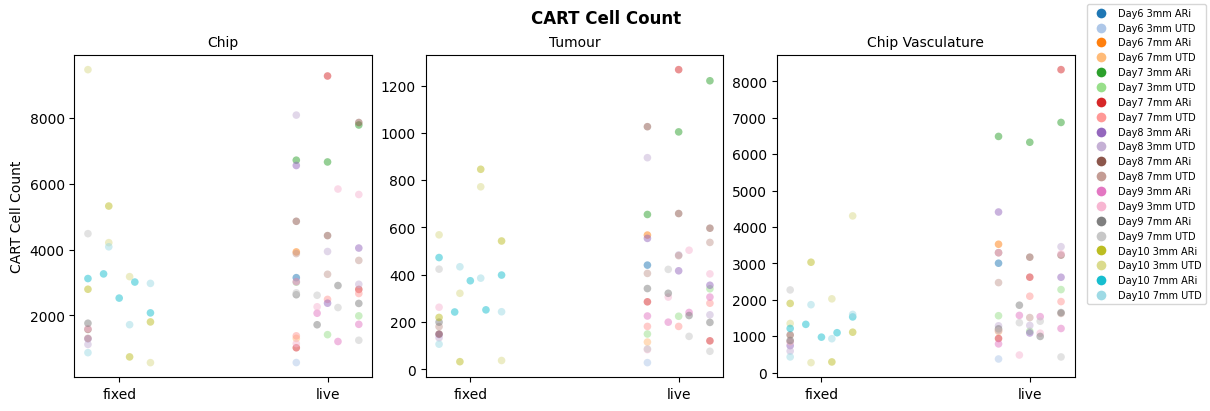

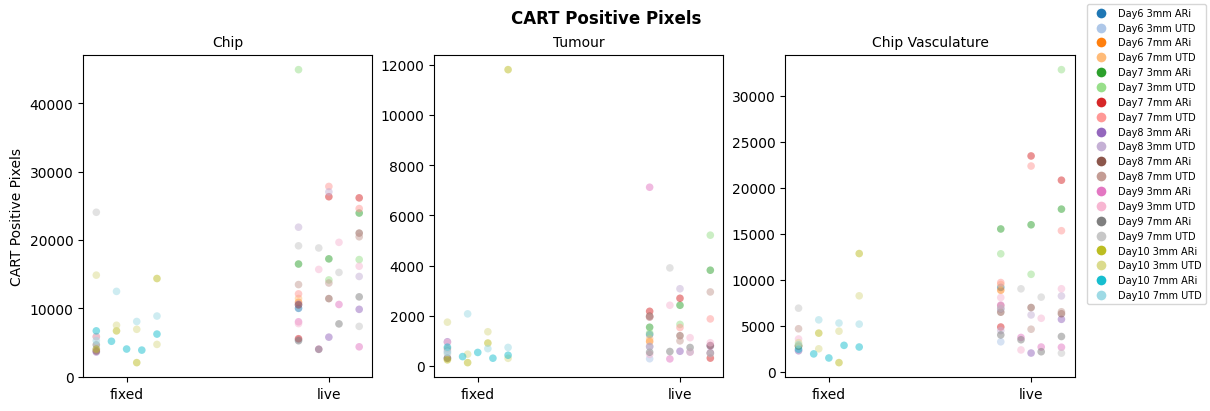

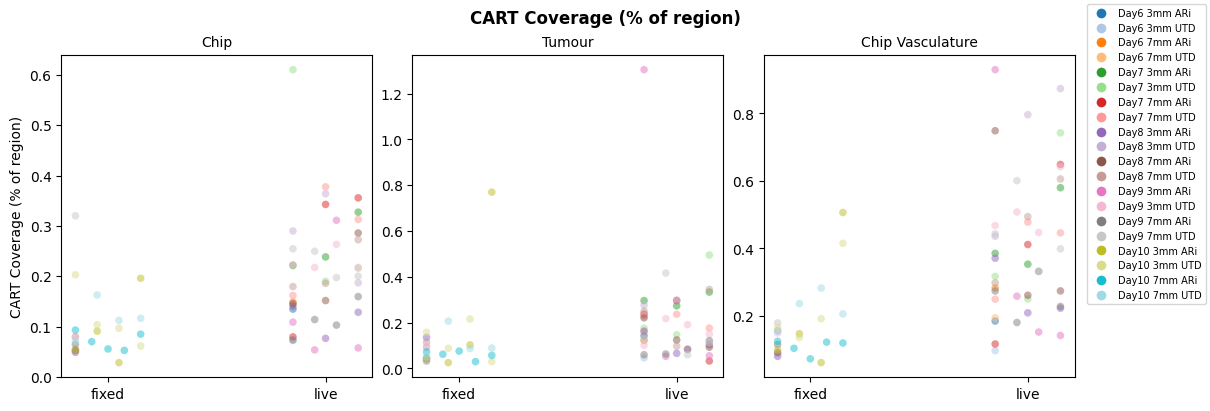

In [ ]:
# ── Scatter: CART cells per fixation, coloured by condition ──────────────────
cart_data = all_results[
    (all_results["cell_type"] == "CART cells") &
    (all_results["region"].isin(["chip", "tumour", "chip_vasculature"])) &
    (all_results["day"] != "unknown")
]
cart_data, condition_order = add_condition_label(cart_data)

fixation_categories = ["fixed", "live"]
plot_regions = ["chip", "tumour", "chip_vasculature"]
metrics = [("cell_count", "CART Cell Count"),
           ("positive_pixels", "CART Positive Pixels"),
           ("positive_pixel_pct", "CART Coverage (% of region)")]

condition_colors = {cond: plt.cm.tab20(i / max(len(condition_order) - 1, 1))
                    for i, cond in enumerate(condition_order)}

for metric, ylabel in metrics:
    fig, axes = plt.subplots(1, len(plot_regions), figsize=(12, 4),
                             sharey=False, constrained_layout=True)
    fig.suptitle(ylabel, fontsize=12, fontweight="bold")

    for ax, region in zip(axes, plot_regions):
        region_data = cart_data[cart_data["region"] == region]
        for fixation_index, fixation in enumerate(fixation_categories):
            fixation_data = region_data[region_data["fixation"] == fixation]
            for condition in condition_order:
                values = fixation_data.loc[fixation_data["condition"] == condition, metric].values
                jitter = np.linspace(-0.15, 0.15, max(len(values), 1))
                for jitter_offset, value in zip(jitter, values):
                    ax.scatter(fixation_index + jitter_offset, value,
                               color=condition_colors[condition], s=30, alpha=0.5,
                               edgecolor="None", linewidth=0.4, zorder=3)
        ax.set_xticks(range(len(fixation_categories)))
        ax.set_xticklabels(fixation_categories, fontsize=10)
        ax.set_title(region.replace("_", " ").title(), fontsize=10)
        ax.set_ylabel(ylabel if ax is axes[0] else "")

    legend_handles = [
        Line2D([0], [0], marker="o", color="w",
               markerfacecolor=condition_colors[c], markersize=8, label=c)
        for c in condition_order
    ]
    fig.legend(handles=legend_handles, loc="outside right upper", fontsize=7, ncol=1)
    fig.savefig(OUTPUT_DIR / f"CART_{metric}_by_condition.png", dpi=150, bbox_inches="tight")
    plt.show()


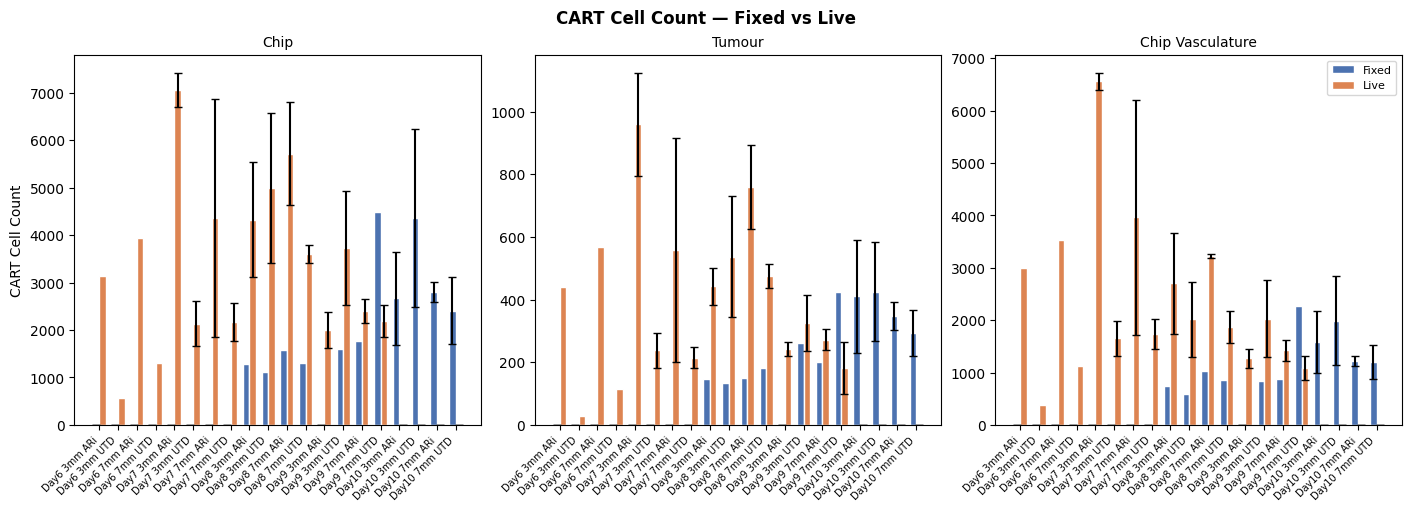

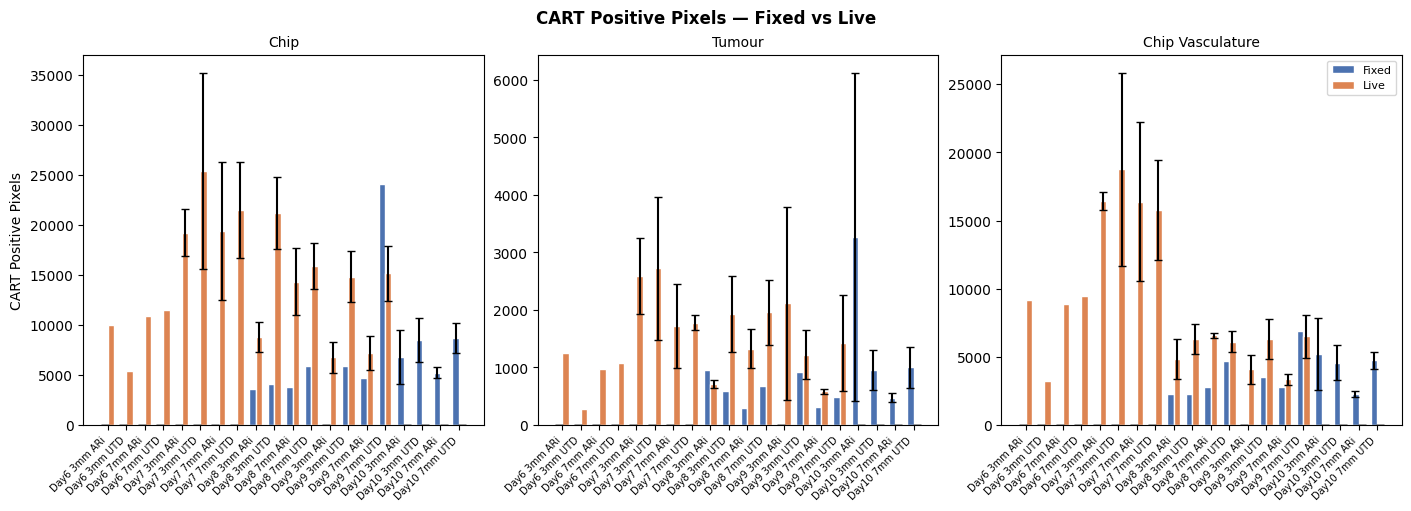

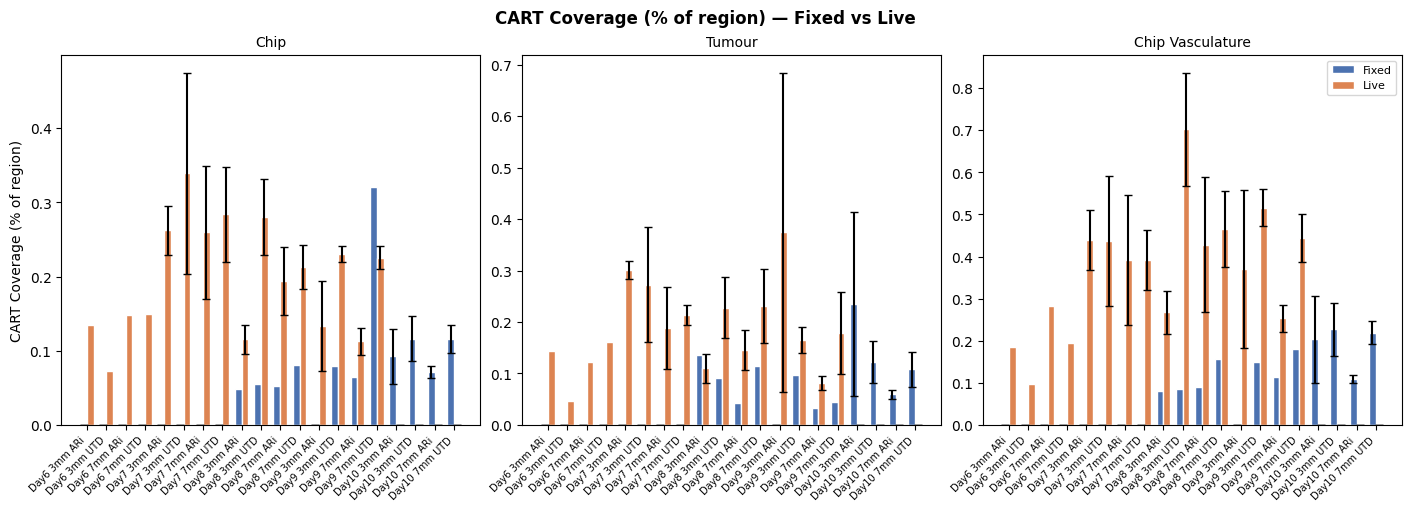

In [ ]:
# ── Bar: Fixed vs Live per condition ─────────────────────────────────────────
cart_bar = all_results[
    (all_results["cell_type"] == "CART cells") &
    (all_results["region"].isin(["chip", "tumour", "chip_vasculature"])) &
    (all_results["day"] != "unknown")
]
cart_bar, condition_order_bar = add_condition_label(cart_bar)

fixation_categories = ["fixed", "live"]
plot_regions = ["chip", "tumour", "chip_vasculature"]
metrics = [("cell_count", "CART Cell Count"),
           ("positive_pixels", "CART Positive Pixels"),
           ("positive_pixel_pct", "CART Coverage (% of region)")]

bar_width = 0.35
fixation_colors = {"fixed": "#4C72B0", "live": "#DD8452"}

for metric, ylabel in metrics:
    fig, axes = plt.subplots(1, len(plot_regions), figsize=(14, 5),
                             sharey=False, constrained_layout=True)
    fig.suptitle(f"{ylabel} — Fixed vs Live", fontsize=12, fontweight="bold")

    for ax, region in zip(axes, plot_regions):
        region_data = cart_bar[cart_bar["region"] == region]
        grouped = region_data.groupby(["condition", "fixation"])[metric]
        means = grouped.mean().unstack(fill_value=0)
        sems = grouped.sem().unstack(fill_value=0)
        for fix in fixation_categories:
            if fix not in means.columns:
                means[fix] = 0.0
                sems[fix] = 0.0
        means = means.reindex([c for c in condition_order_bar if c in means.index])
        sems = sems.reindex(means.index)

        x = np.arange(len(means))
        ax.bar(x - bar_width / 2, means["fixed"], bar_width,
               yerr=sems["fixed"], capsize=3, color=fixation_colors["fixed"],
               edgecolor="white", label="Fixed")
        ax.bar(x + bar_width / 2, means["live"], bar_width,
               yerr=sems["live"], capsize=3, color=fixation_colors["live"],
               edgecolor="white", label="Live")
        ax.set_xticks(x)
        ax.set_xticklabels(means.index, fontsize=7, rotation=45, ha="right")
        ax.set_title(region.replace("_", " ").title(), fontsize=10)
        ax.set_ylabel(ylabel if ax is axes[0] else "")

    axes[-1].legend(fontsize=8)
    fig.savefig(OUTPUT_DIR / f"CART_{metric}_fixed_vs_live.png", dpi=150, bbox_inches="tight")
    plt.show()


                       image               region  positive_pixels  cart_px_chip  region_area_px  area_chip  cart_enrichment
  Day6_Plate2_ARi_3mm_Merged               tumour             1245         10018          872268    7422132         0.014605
  Day6_Plate2_ARi_3mm_Merged     chip_vasculature             9174         10018         4972514    7422132         0.613515
  Day6_Plate2_ARi_3mm_Merged chip_not_vasculature              844         10018         2449618    7422132         0.027806
  Day6_Plate2_ARi_7mm_Merged               tumour              968         10891          792198    7369240         0.009555
  Day6_Plate2_ARi_7mm_Merged     chip_vasculature             8859         10891         3137063    7369240         0.346272
  Day6_Plate2_ARi_7mm_Merged chip_not_vasculature             2032         10891         4232177    7369240         0.107151
  Day6_Plate2_UTD_3mm_Merged               tumour              278          5409          608249    7454461         0.004194


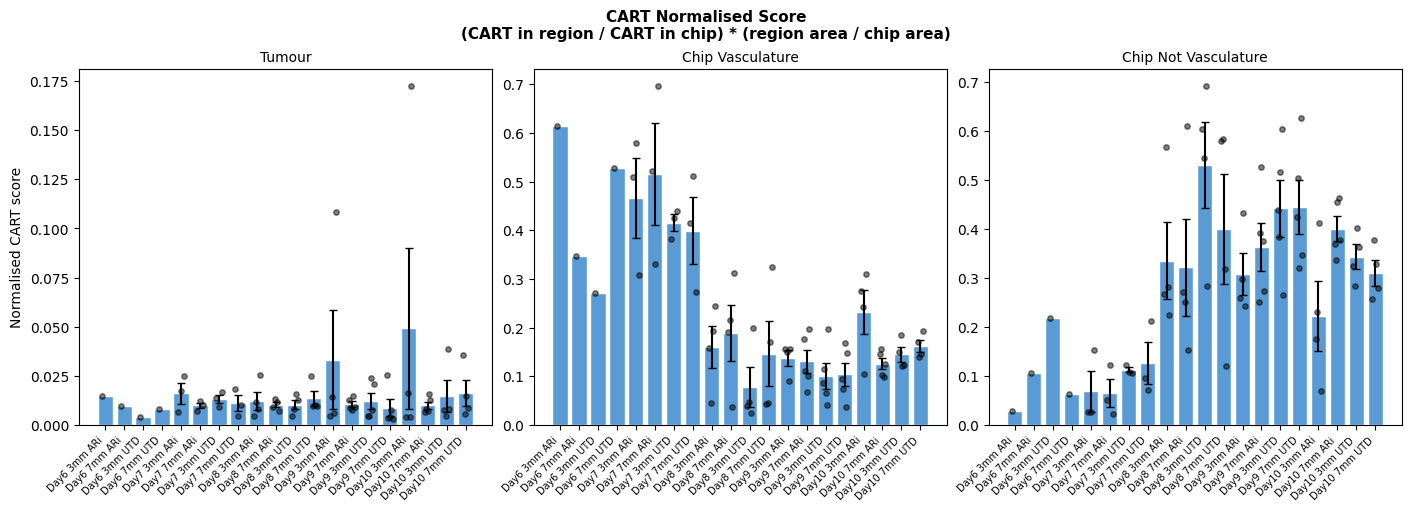

In [ ]:
# ── Normalised CART enrichment per region ────────────────────────────────────
# Formula: (CART_px_in_region / CART_px_in_chip) * (region_area / chip_area)
enrichment_regions = ["tumour", "chip_vasculature", "chip_not_vasculature"]

cart_all = all_results[all_results["cell_type"] == "CART cells"].copy()
chip_rows = cart_all[cart_all["region"] == "chip"][
    ["image", "positive_pixels", "region_area_px"]
].rename(columns={"positive_pixels": "cart_px_chip", "region_area_px": "area_chip"})

enrichment = cart_all[cart_all["region"].isin(enrichment_regions)].merge(
    chip_rows, on="image", how="left")
enrichment["cart_enrichment"] = (
    (enrichment["positive_pixels"] / enrichment["cart_px_chip"].replace(0, np.nan)) *
    (enrichment["region_area_px"]  / enrichment["area_chip"].replace(0, np.nan))
)
enrichment, _ = add_condition_label(enrichment)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, len(enrichment_regions), figsize=(14, 5),
                         sharey=False, constrained_layout=True)
fig.suptitle("CART Normalised Score\n(CART in region / CART in chip) * (region area / chip area)",
             fontsize=11, fontweight="bold")

for ax, region in zip(axes, enrichment_regions):
    region_data = enrichment[enrichment["region"] == region]
    conditions = list(dict.fromkeys(region_data["condition"]))
    x_positions = np.arange(len(conditions))
    means = [region_data.loc[region_data["condition"] == c, "cart_enrichment"].mean() for c in conditions]
    sems  = [region_data.loc[region_data["condition"] == c, "cart_enrichment"].sem()  for c in conditions]
    ax.bar(x_positions, means, yerr=sems, capsize=3, color="#5A9BD5", edgecolor="white")
    for xi, c in enumerate(conditions):
        vals = region_data.loc[region_data["condition"] == c, "cart_enrichment"].values
        jitter = np.linspace(-0.15, 0.15, max(len(vals), 1))
        for j, v in zip(jitter, vals):
            ax.scatter(xi + j, v, color="black", s=15, alpha=0.5, zorder=5)
    ax.set_xticks(x_positions)
    ax.set_xticklabels(conditions, fontsize=7, rotation=45, ha="right")
    ax.set_title(region.replace("_", " ").title(), fontsize=10)
    ax.set_ylabel("Normalised CART score" if ax is axes[0] else "")

fig.savefig(OUTPUT_DIR / "CART_normalised_enrichment.png", dpi=150, bbox_inches="tight")
plt.show()

enrichment.to_csv(OUTPUT_DIR / "enrichment_quantities.csv", index=False)
print(f"Saved enrichment CSV → {OUTPUT_DIR / 'enrichment_quantities.csv'}")
